In [15]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import zarr
import os
import sys

sys.path.append(os.path.abspath(".."))

from libs import AFT_tools as AFT

plt.style.use('../libs/my_style.mplstyle')

markers = ["o", "s", "v", "^", '*', 'd']
lines = ["-", "--", "-.", ":", (0, (5, 3, 1, 3, 1, 3))]

path = '/Volumes/My Passport/Sasaki/MTsingleBeads/20260107/MTs.zarr'
path2='/Volumes/My Passport/Sasaki/MTsingleBeads/20241114/T2_4uM_mc03_beads_zarr/MTs.zarr'

path3='/Volumes/My Passport/Sasaki/MTsingleBeads/20241114/T2_4uM_mc03_zarr/MTs.zarr'

za = zarr.open_array(path2, read_only=True)
#MTs = za[:]

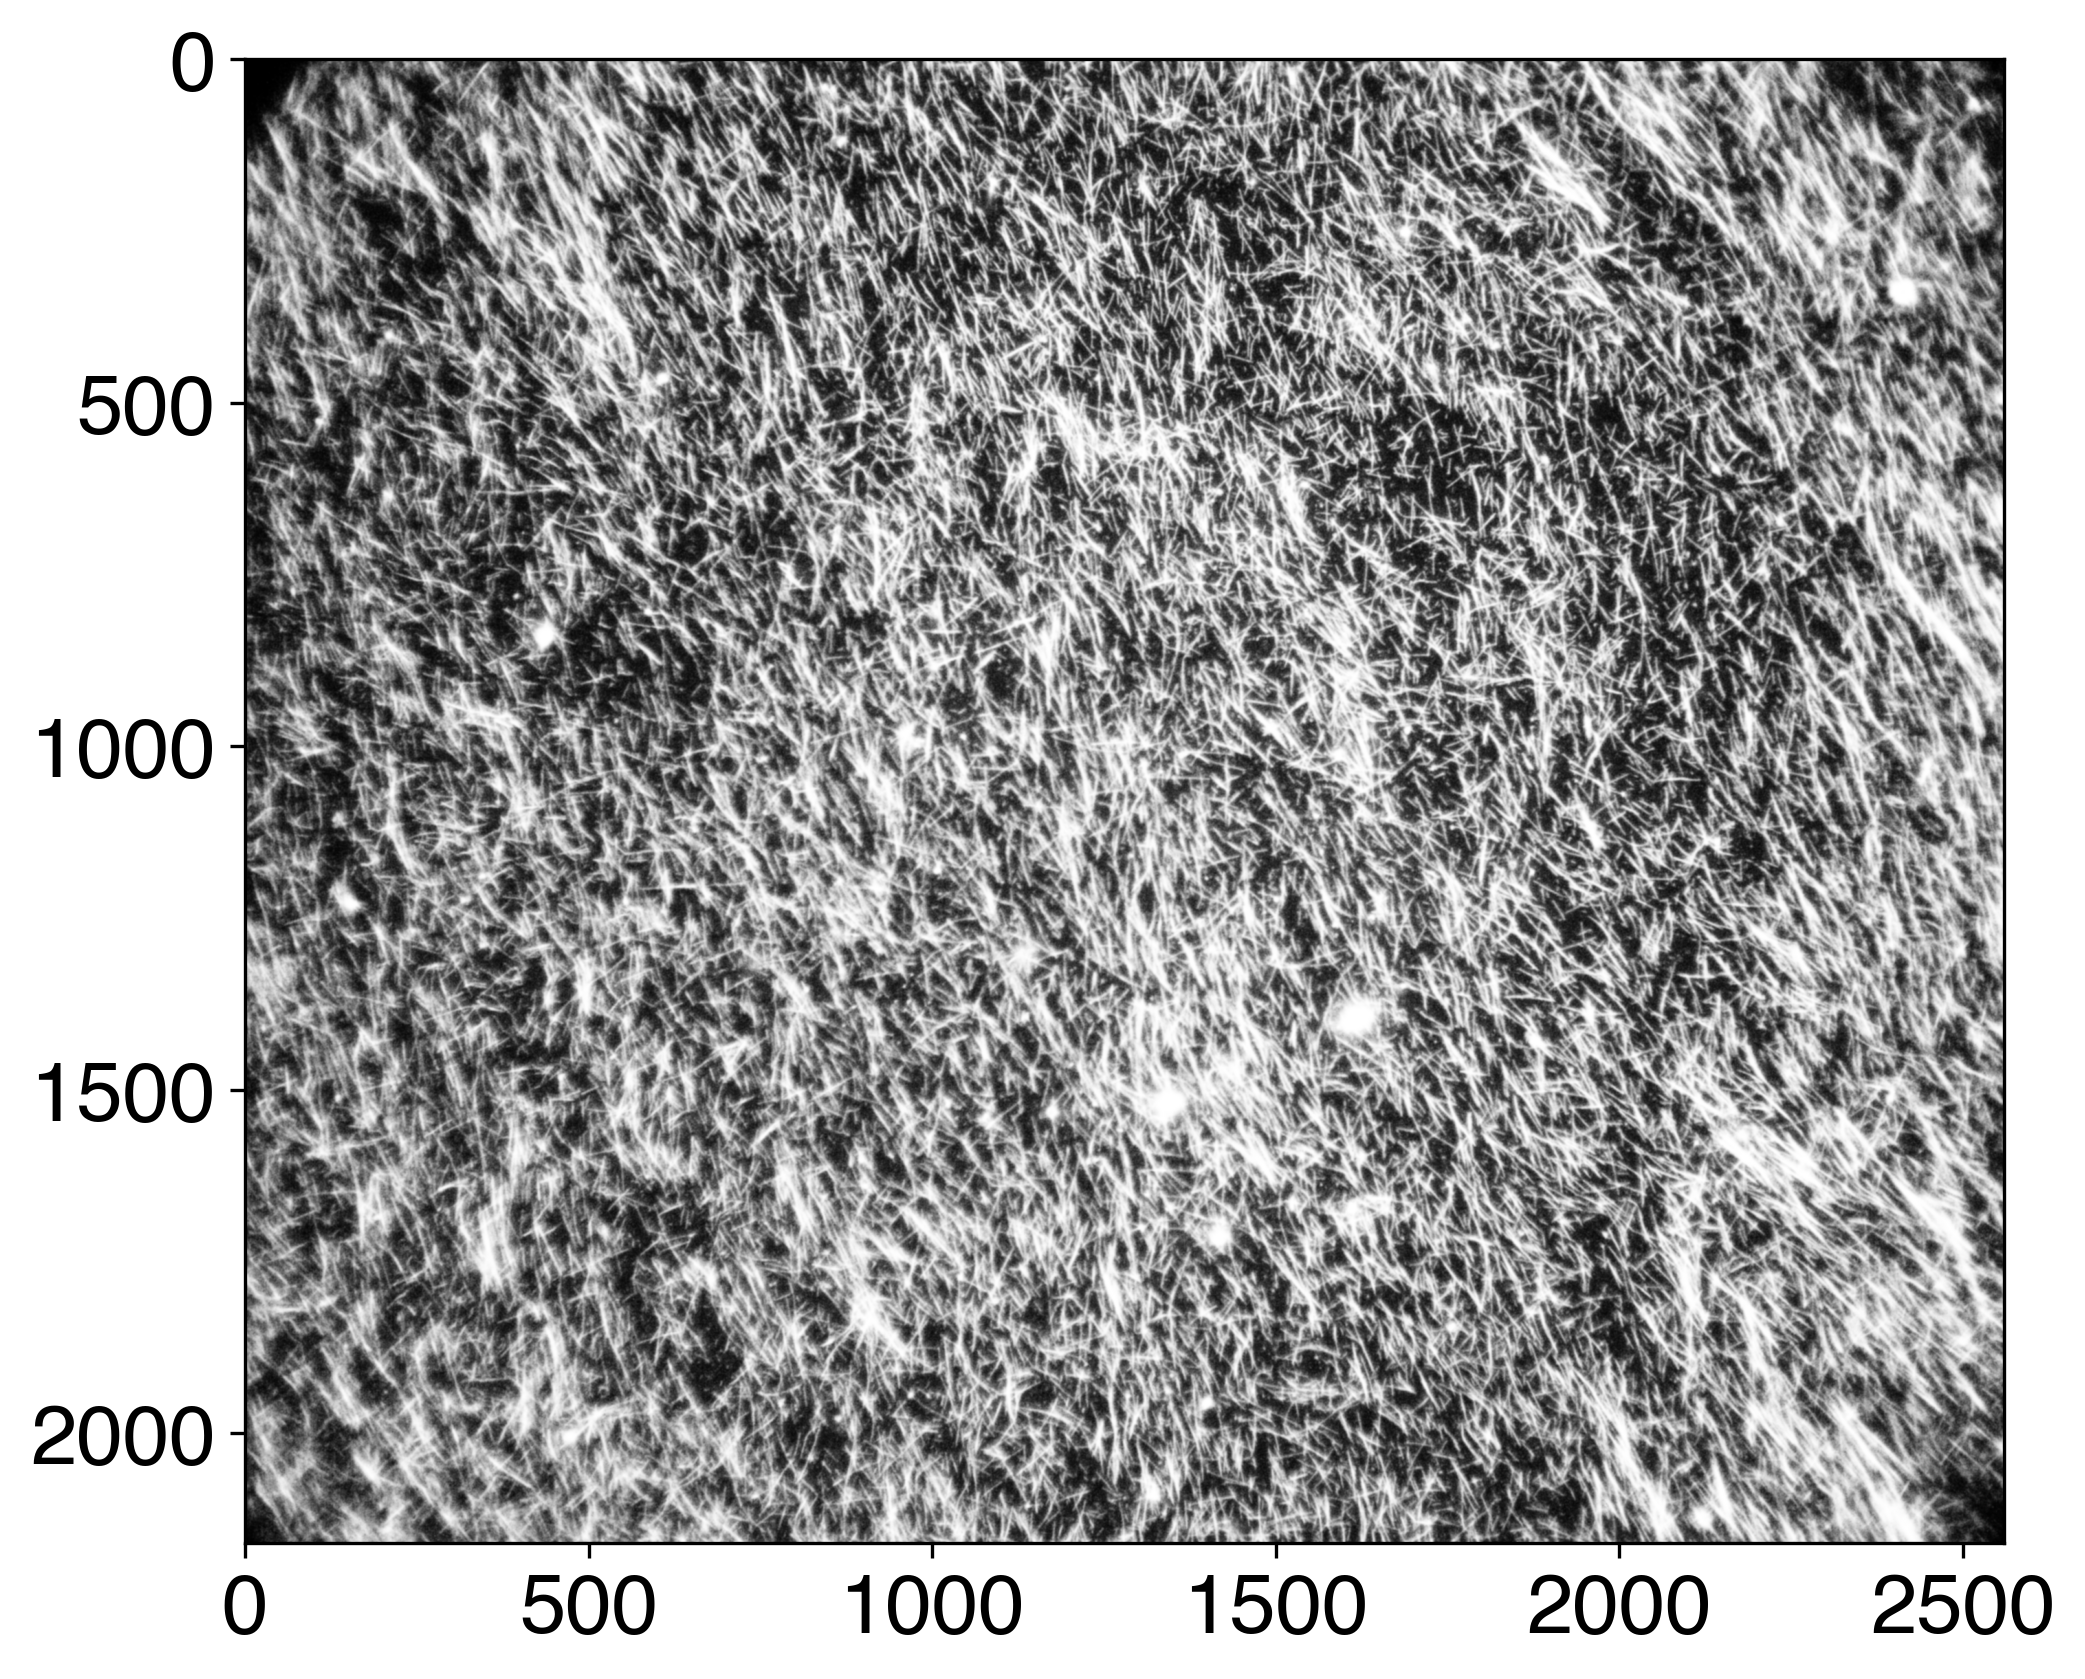

In [16]:
plt.imshow(za[0, :, :], cmap='gray')

In [17]:
# AFT parameters
window_size_um = 10 # MTs length = 10um
frame = 100

scale = 0.11  # um/pixel

#### required parameters ####
window_size = int(window_size_um/scale)
overlap = 0.8
neighborhood_radius = 1

d = 30

#crop, mask = crop_around_trajectory(traj_solo, MTs_smoothed, d, scale)

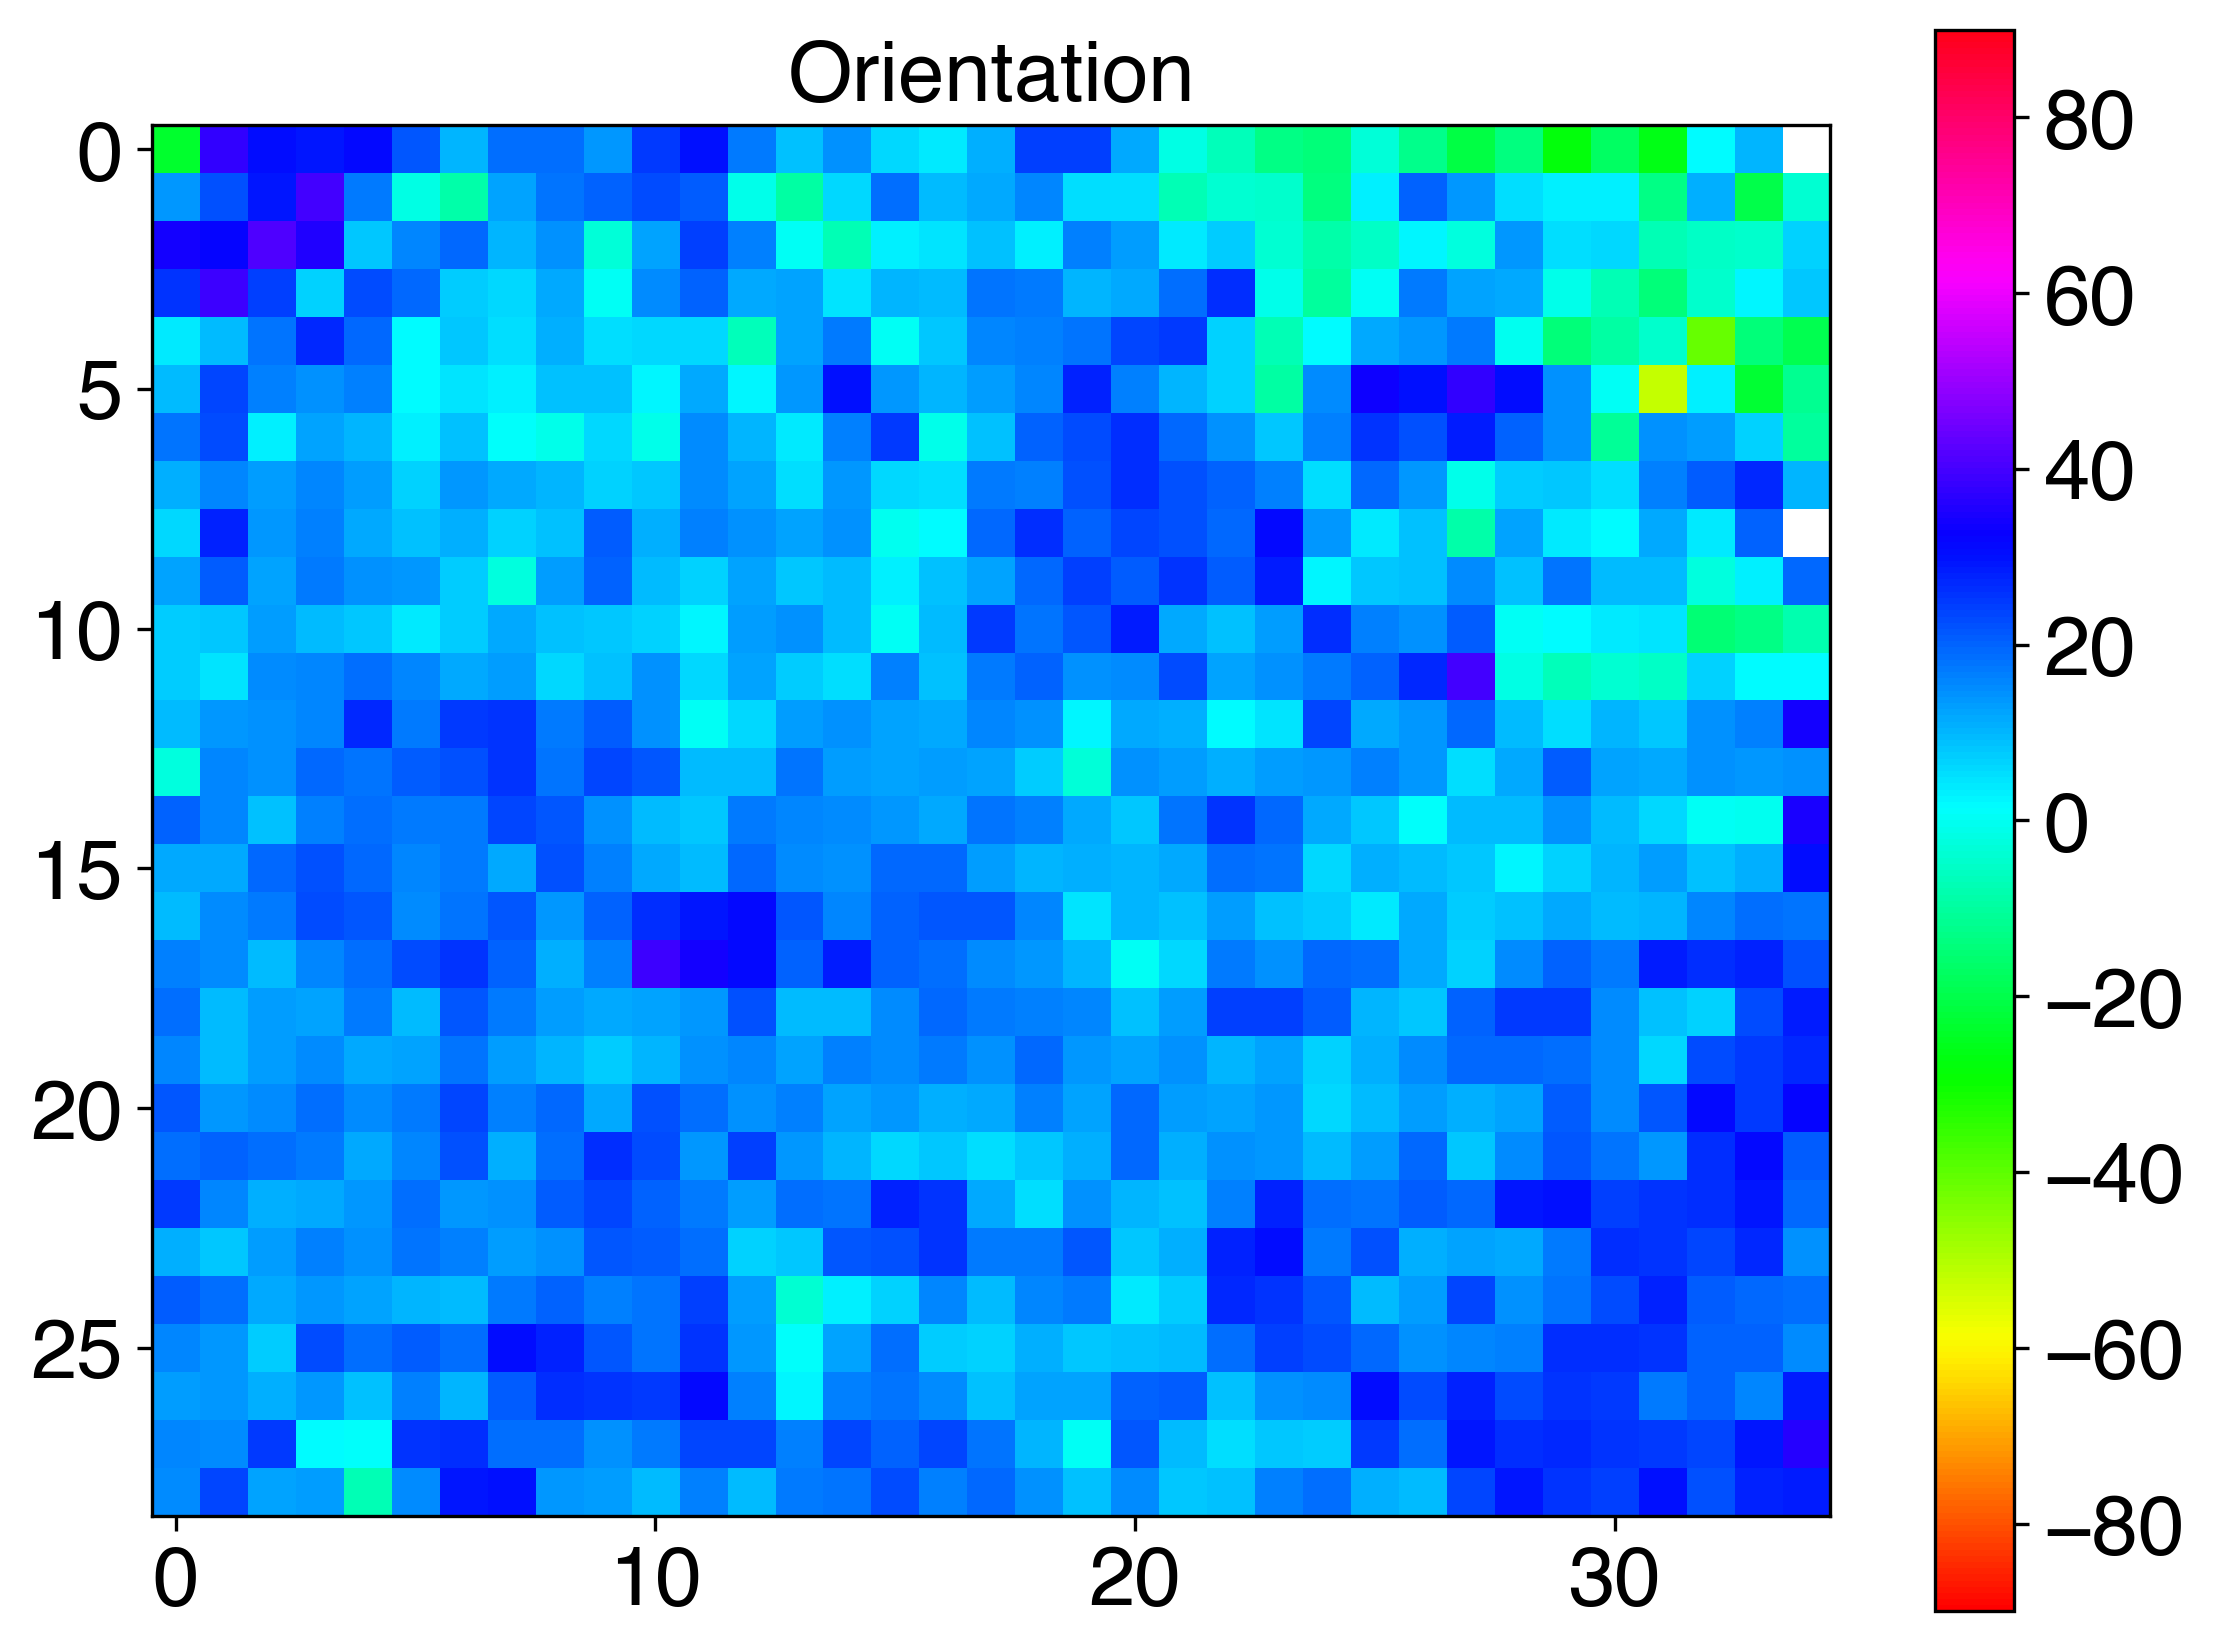

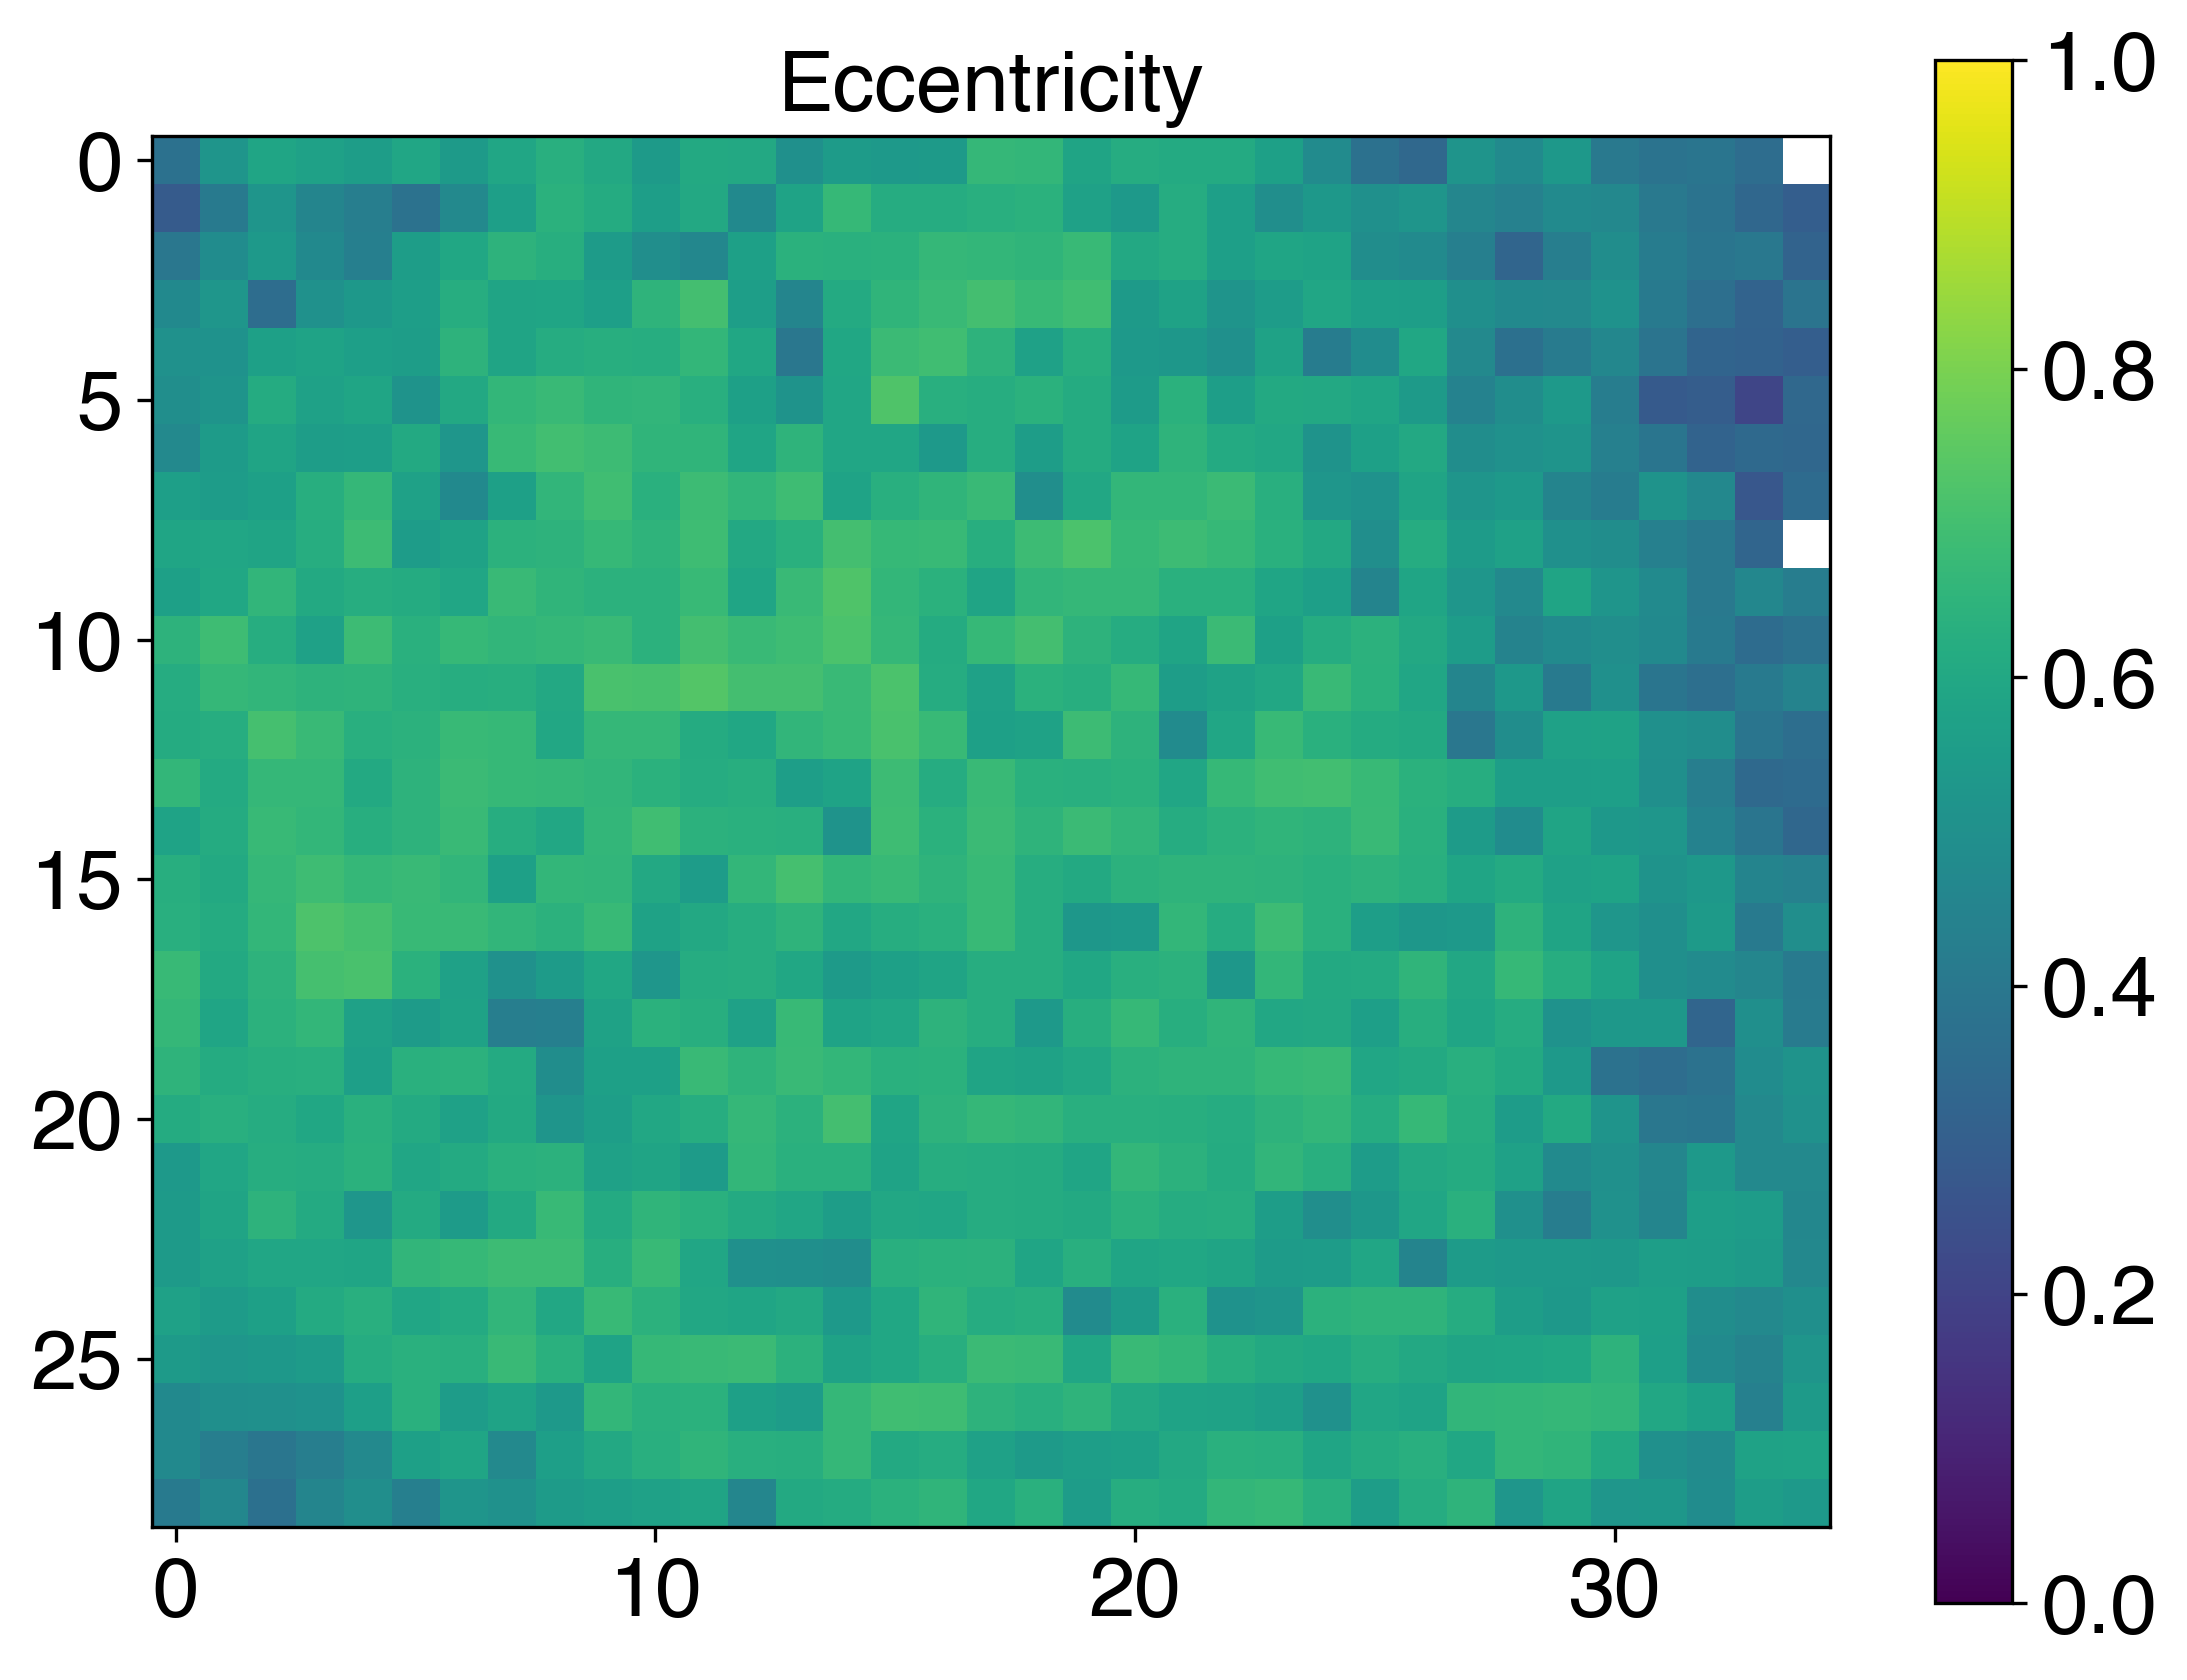

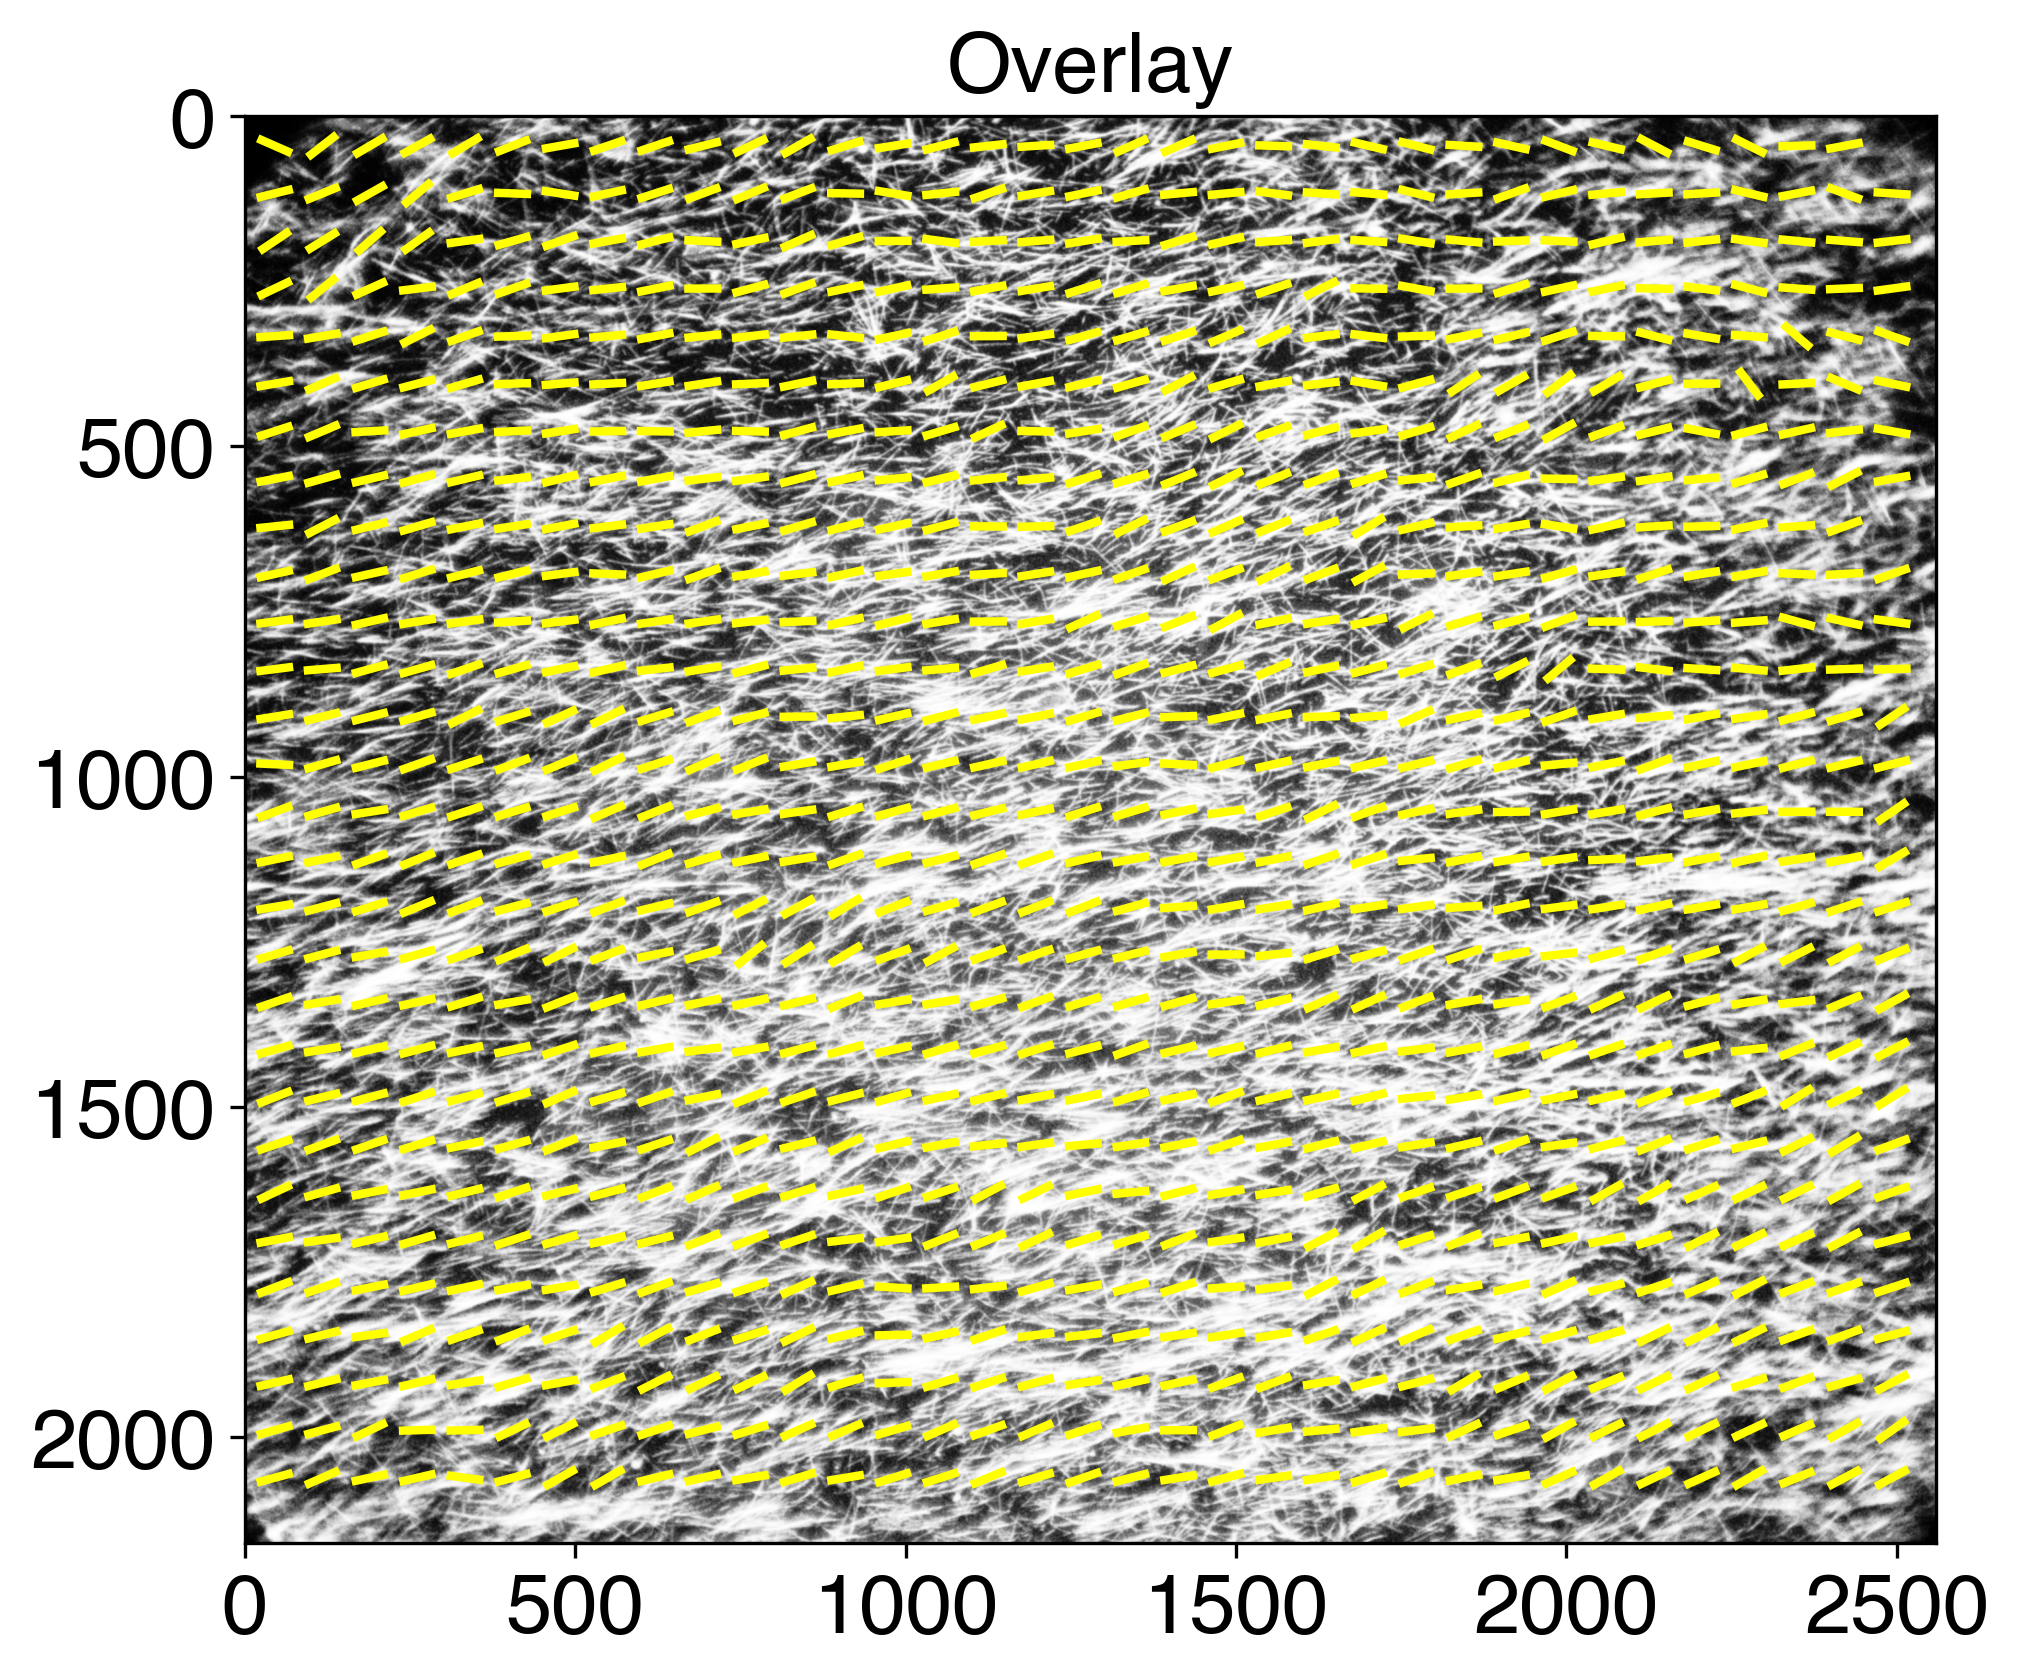

(array([  45,  117,  189, ..., 2349, 2421, 2493], shape=(1015,)),
 array([  45,   45,   45, ..., 2061, 2061, 2061], shape=(1015,)),
 array([20.59362235, 17.765694  , 19.37479027, ..., 20.83887934,
        19.86752811, 19.76196997], shape=(1015,)),
 array([-9.06381368, 13.80688657, 11.43973347, ...,  8.48475738,
        10.5608393 , 10.75706943], shape=(1015,)),
 array([[-0.41461345,  0.66066163,  0.53336358, ...,  0.02752961,
          0.18286249,         nan],
        [ 0.24256476,  0.38800091,  0.51293134, ...,  0.18775758,
         -0.35568536, -0.06770042],
        [ 0.5918467 ,  0.55443127,  0.71817196, ..., -0.09692631,
         -0.07765304,  0.11347773],
        ...,
        [ 0.22453088,  0.23920181,  0.18651947, ...,  0.35508092,
          0.27239867,  0.4944728 ],
        [ 0.27775146,  0.25913041,  0.44084204, ...,  0.40677217,
          0.51497391,  0.62603286],
        [ 0.2635946 ,  0.41251591,  0.20976963, ...,  0.38666348,
          0.48857789,  0.49848104]], shape=(29,

In [5]:
AFT.image_local_order(za[0,:,:], window_size, overlap, save_path='', eccentricity_thresh = 0.2,
                                                             plot_overlay=True, plot_angles=True, plot_eccentricity=True,
                                                             save_figures=False)

In [18]:
x, y, u, v, im_theta, im_eccentricity = AFT.image_local_order(za[:,:,:], window_size, overlap, save_path='', eccentricity_thresh = 0.2,
                                                             plot_overlay=False, plot_angles=False, plot_eccentricity=False,
                                                             save_figures=False)

[Text(0.5, 0, 't[s]'), Text(0, 0.5, 'Order parameter'), (0.0, 1.0)]

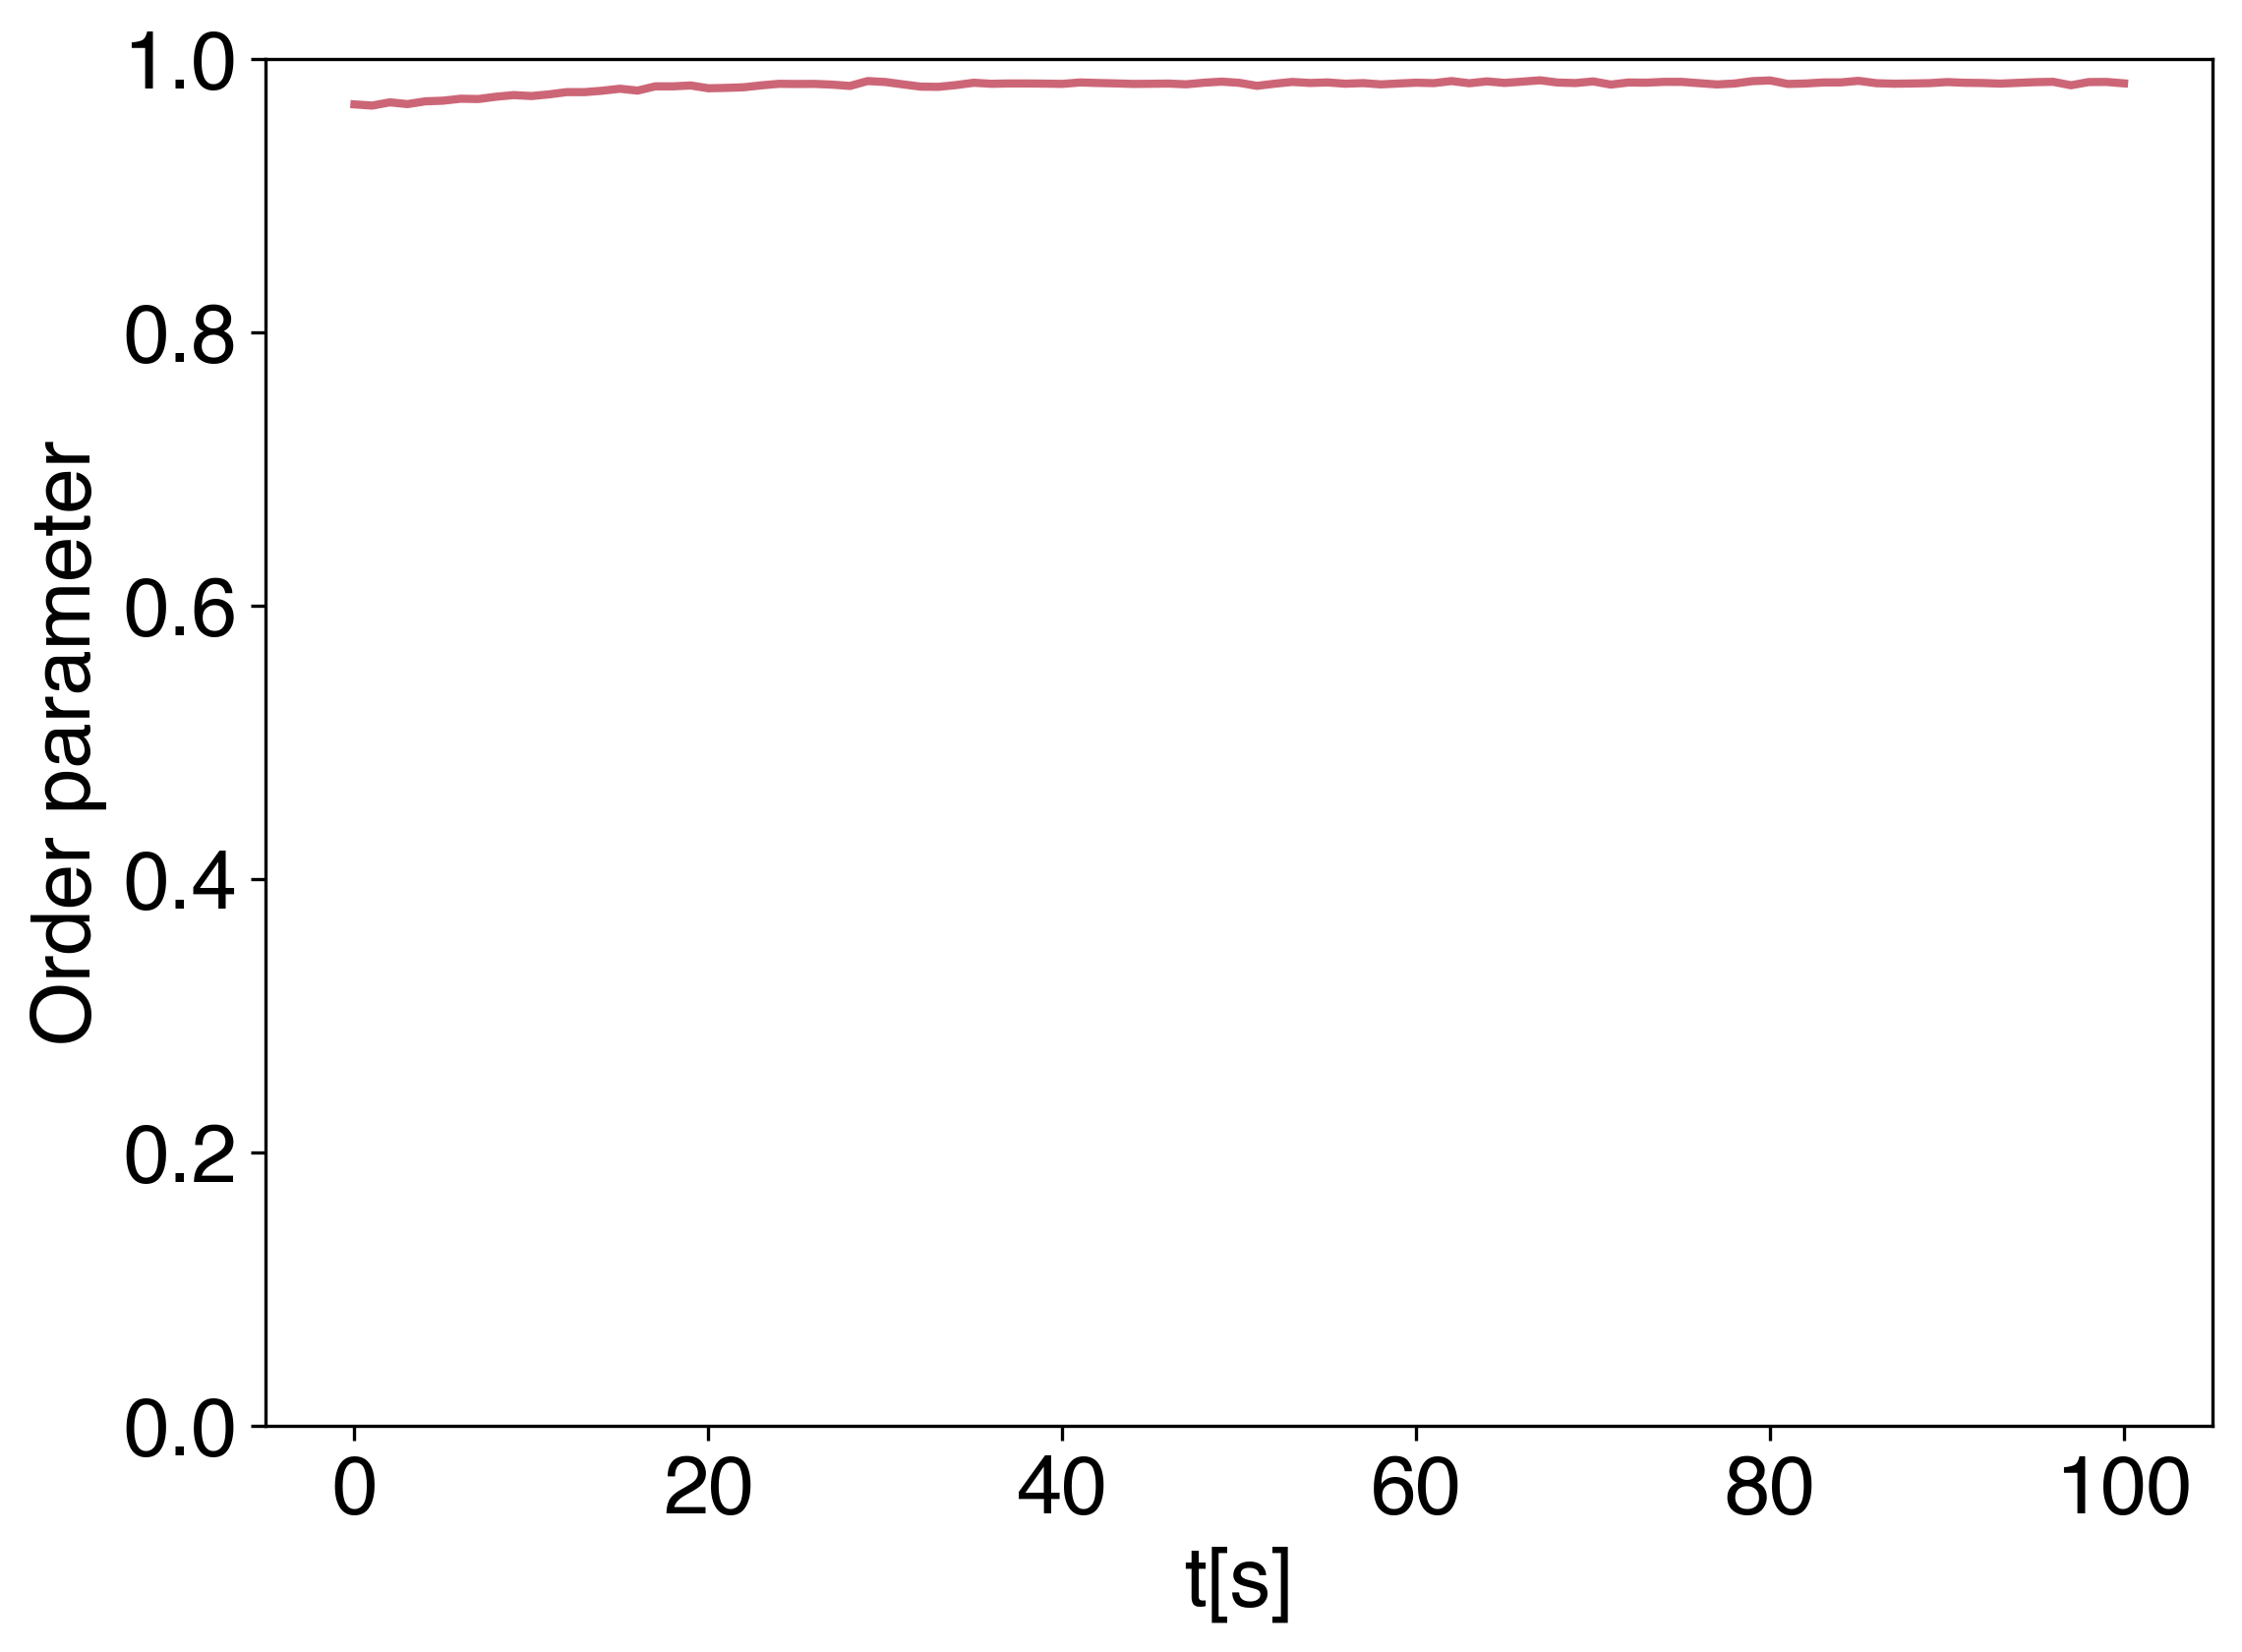

In [8]:
im_order_parameter = AFT.calculate_order_parameter(im_theta, neighborhood_radius)

fig, ax = plt.subplots()
ax.plot( im_order_parameter)

ax.set(xlabel='t[s]',
       ylabel='Order parameter',
       ylim=(0, 1))

#print('The order parameter is {0}'.format(im_order_parameter))

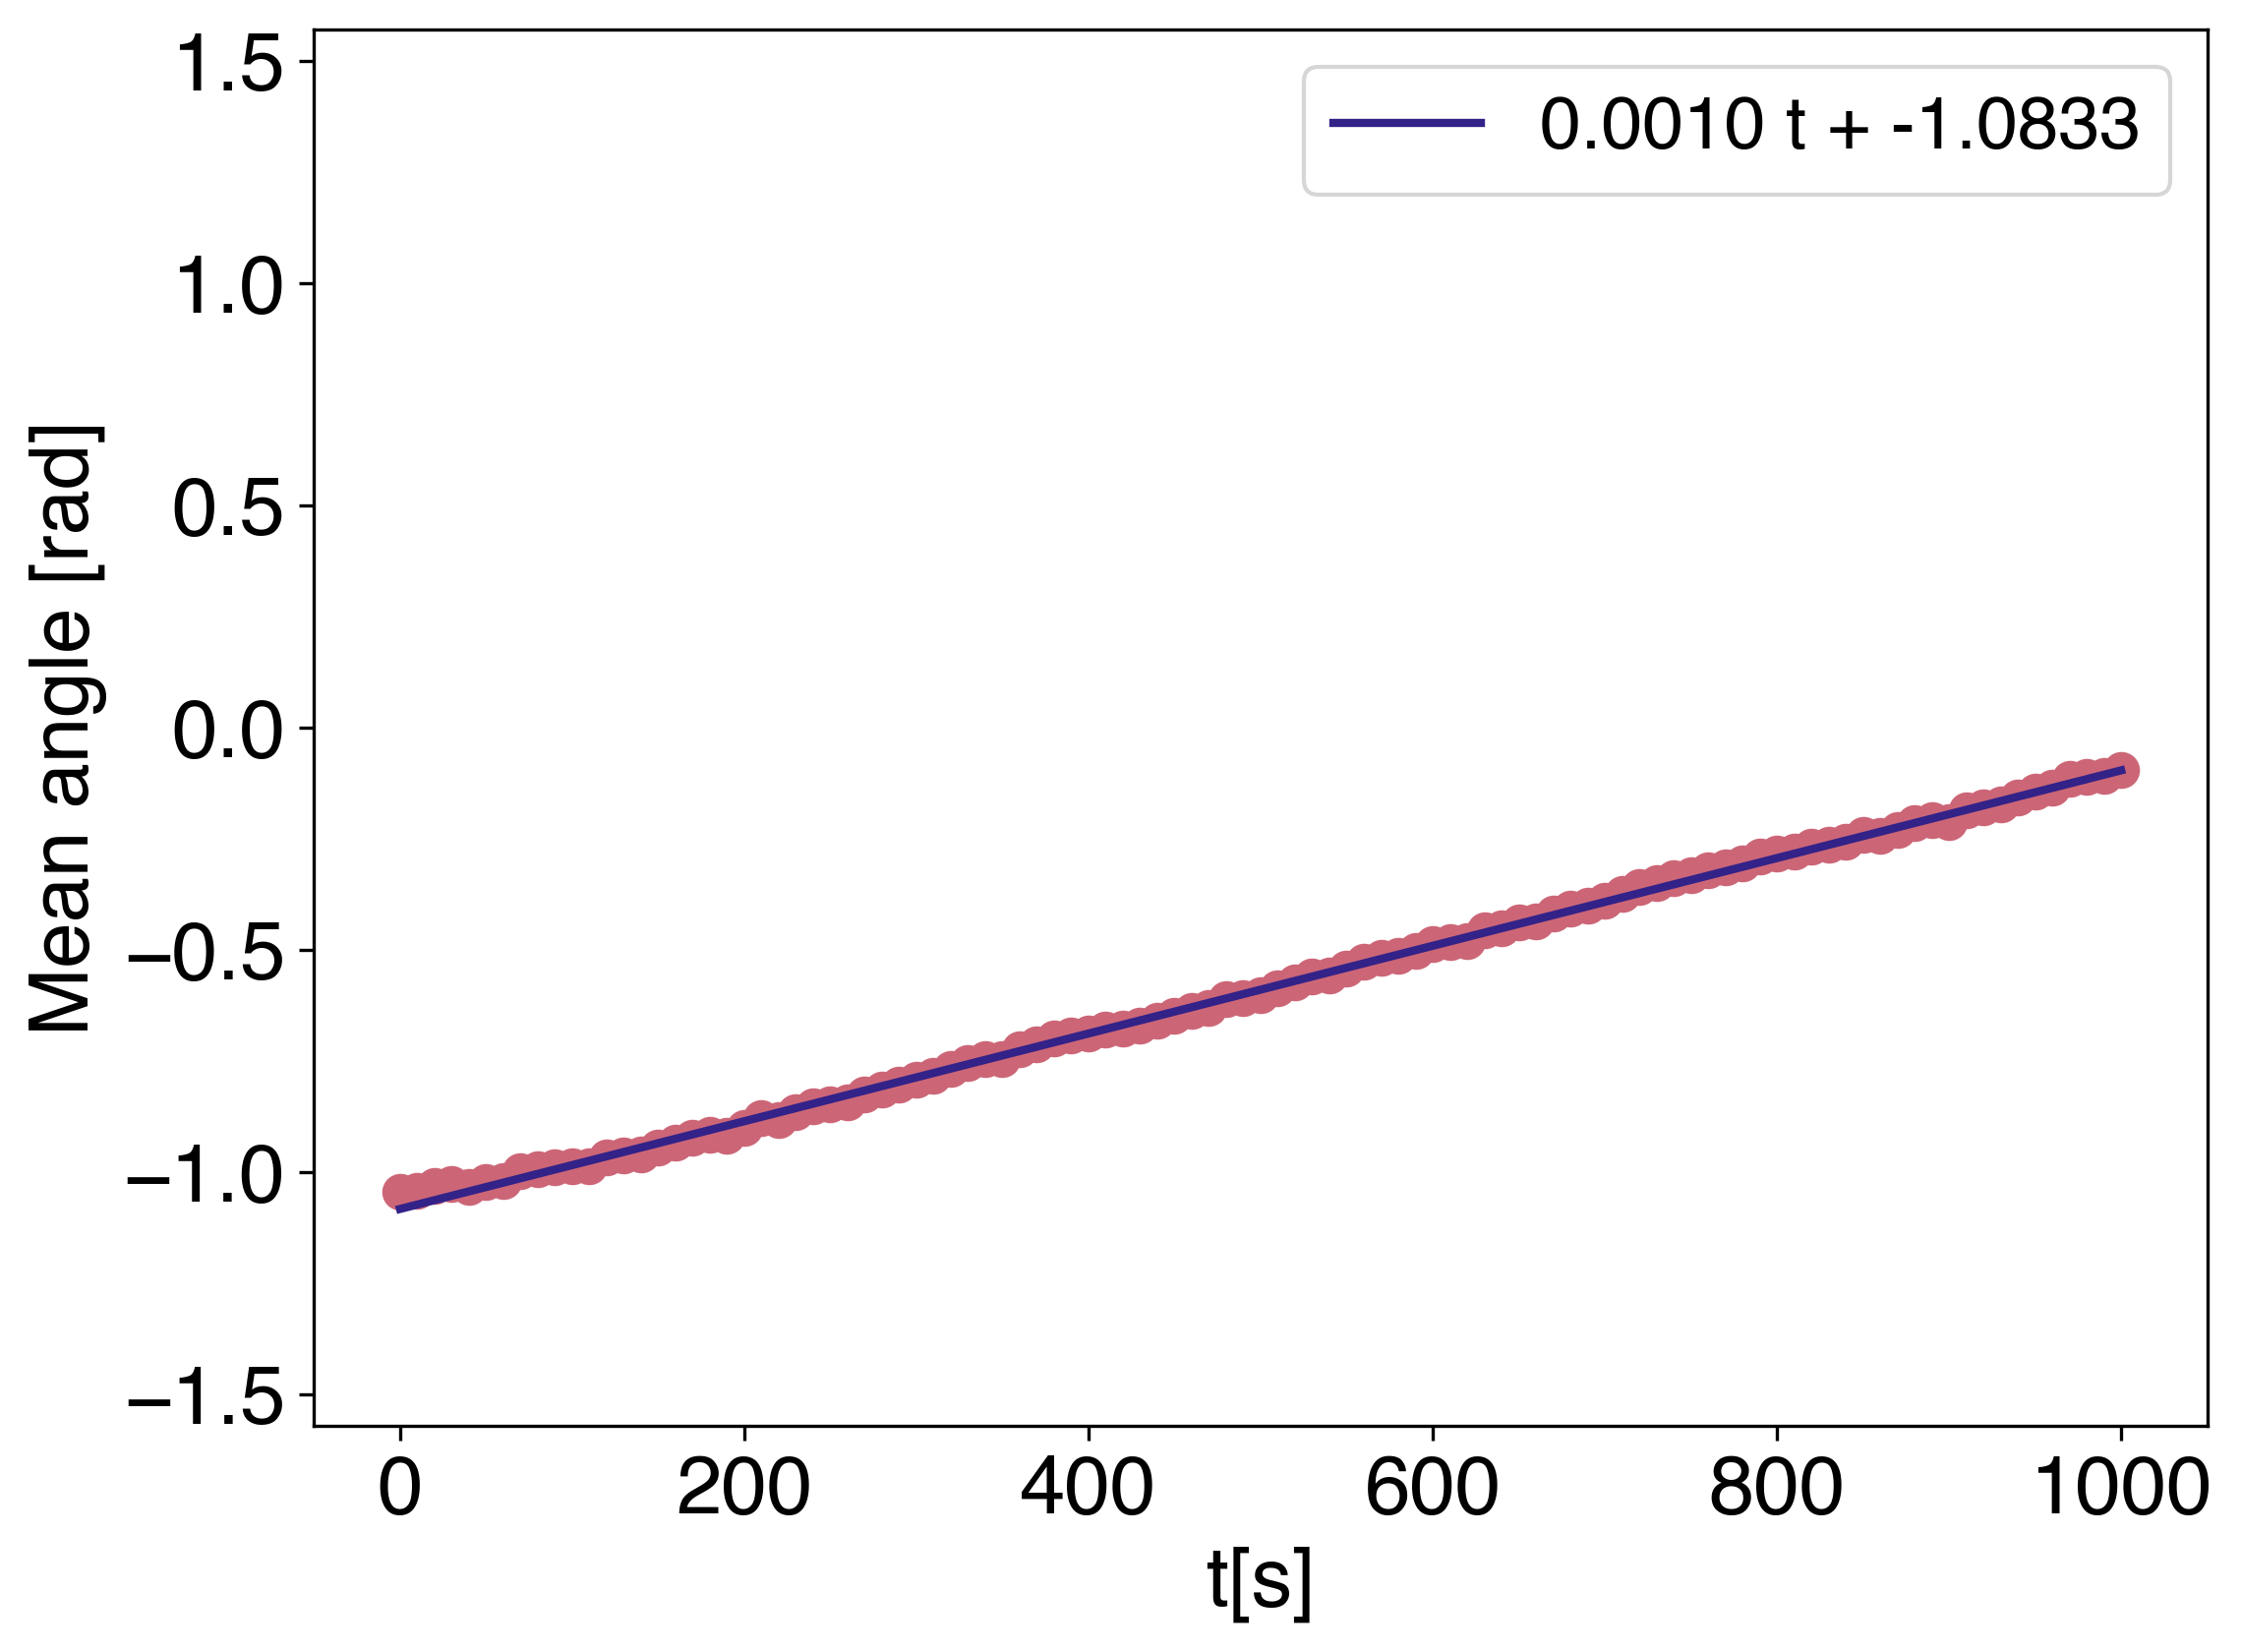

In [19]:
means = []
for theta in im_theta:
    mean = np.arctan2(np.nansum(np.sin(theta)), np.nansum(np.cos(theta)))
    means.append(mean)
    
fig, ax = plt.subplots()
ax.plot(np.arange(len(means))*10, means, marker='o', linestyle='None')
ax.set(xlabel='t[s]',
       ylabel='Mean angle [rad]',
       ylim=(-np.pi/2, np.pi/2))

from scipy.optimize import curve_fit

def fit(x, a, b):
    return a * x + b
popt, pcov = curve_fit(fit, np.arange(len(means))*10, means)

ax.plot(np.arange(len(means))*10, fit(np.arange(len(means))*10, *popt), label = f'{popt[0]:.4f} t + {popt[1]:.4f}')
ax.legend()

In [44]:
za2 = zarr.open_array(path2, read_only=True)
x2, y2, u2, v2, im_theta2, im_eccentricity2 = AFT.image_local_order(za2[:,:,:], window_size, overlap, save_path='', eccentricity_thresh = 0.2,
                                                             plot_overlay=False, plot_angles=False, plot_eccentricity=False,
                                                             save_figures=False)

[Text(0.5, 0, 't[s]'),
 Text(0, 0.5, 'Mean angle [rad]'),
 (-1.5707963267948966, 1.5707963267948966)]

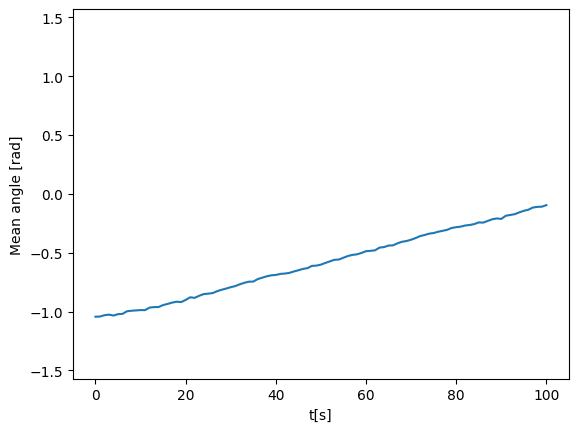

In [46]:
means2 = []
for theta in im_theta2:
    mean = np.arctan2(np.nansum(np.sin(theta)), np.nansum(np.cos(theta)))
    means2.append(mean)


fig, ax = plt.subplots()
ax.plot(means2)
ax.set(xlabel='t[s]',
       ylabel='Mean angle [rad]',
       ylim=(-np.pi/2, np.pi/2))

[Text(0.5, 0, 't[s]'), Text(0, 0.5, 'Order parameter'), (0.0, 1.0)]

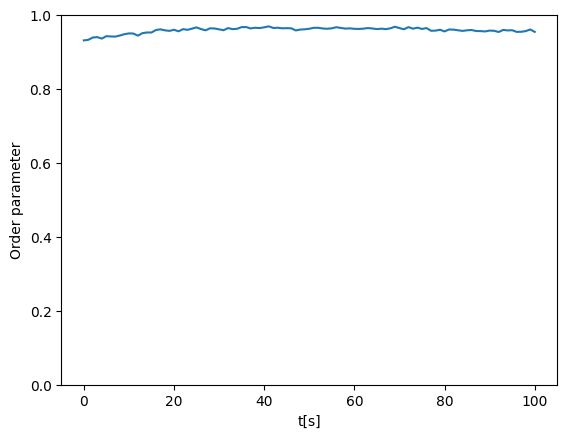

In [47]:
im_order_parameter2 = AFT.calculate_order_parameter(im_theta2, neighborhood_radius)

fig, ax = plt.subplots()
ax.plot(im_order_parameter2)

ax.set(xlabel='t[s]',
       ylabel='Order parameter',
       ylim=(0, 1))